This notebook is a Work in Progress summary of the workflow and its tools

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import os
import numpy as np
import torch

In [2]:
from tools import smiles_to_graph

Use PolyMetriX for datasets (with features)
https://github.com/lamalab-org/PolyMetriX

In [3]:
# Import necessary modules
from polymetrix.datasets import CuratedGlassTempDataset

# Load the dataset
dataset = CuratedGlassTempDataset()
print("Available features:", dataset.available_features)
print("Available labels:", dataset.available_labels)
print("Available metadata:", dataset.meta_info)

Available features: ['sidechainlevel.features.num_atoms_sidechainfeaturizer_sum', 'sidechainlevel.features.num_atoms_sidechainfeaturizer_mean', 'sidechainlevel.features.num_atoms_sidechainfeaturizer_max', 'sidechainlevel.features.num_atoms_sidechainfeaturizer_min', 'sidechainlevel.features.numsidechainfeaturizer', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_mean', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_min', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_max', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_sum', 'sidechainlevel.features.star_to_sidechain_min_distance_mean', 'sidechainlevel.features.star_to_sidechain_min_distance_min', 'sidechainlevel.features.star_to_sidechain_min_distance_max', 'sidechainlevel.features.star_to_sidechain_min_distance_sum', 'sidechainlevel.features.num_diverse_sidechains', 'sidechainlevel.features.balaban_j_index_sidechainfeaturizer

c:\Users\pablo\miniconda3\envs\molproprenet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


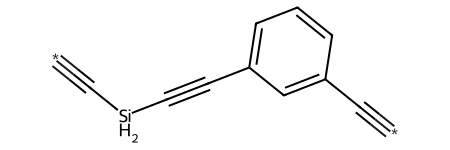

In [4]:
psmiles = dataset.psmiles[0]
pol = Chem.MolFromSmiles(psmiles)
pol

Transform a SMILES to a PyG graph

In [5]:
data = smiles_to_graph(Chem.MolToSmiles(pol))
print(data.x.shape, data.edge_index.shape, len(pol.GetAtoms()),len(pol.GetBonds()))

torch.Size([13, 6]) torch.Size([2, 26]) 13 13


In [6]:
type(dataset)

polymetrix.datasets.curated_tg_dataset.CuratedGlassTempDataset

In [7]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

list_datas = []
for psmiles, exp_tg in zip(dataset.psmiles, dataset._labels):
    data = smiles_to_graph(psmiles)
    data.y = torch.tensor(exp_tg,dtype=torch.float32)
    list_datas.append(data)

N = len(list_datas)
train_size = int(0.8*N)
val_size = int(0.1*N)
test_size = N - train_size - val_size
train,val,test = random_split(list_datas,[train_size, val_size, test_size])

train_loader = DataLoader(train,batch_size=32,shuffle=True)
val_loader = DataLoader(val,batch_size=32)
test_loader = DataLoader(test,batch_size=32)

In [10]:
import torch
from torch import Tensor
from torch_geometric.nn import GCNConv, global_mean_pool, Linear
from torch.nn import ReLU


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.head = Linear(out_channels,1)

    def forward(self, x: Tensor, edge_index: Tensor, batch: Tensor) -> Tensor:
        # x: Node feature matrix of shape [num_nodes, in_channels]
        # edge_index: Graph connectivity matrix of shape [2, num_edges]
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = self.head(x)
        return x

model = GCN(6, 64, 32)

model.load_state_dict(torch.load("model.pt"))

<All keys matched successfully>

In [11]:
learning_rate = 0.001
max_iters = 50
lowest_mse_loss = np.inf

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
mseloss = torch.nn.MSELoss()
maeloss = torch.nn.L1Loss()

# Save the train_loss and val_loss during training
train_loss_list = []
val_loss_list = []


for iter in range(max_iters):
    # Training
    total_loss = 0
    for batch_data in train_loader:
        optimizer.zero_grad(set_to_none=True)
        out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
        loss = mseloss(out,batch_data.y.reshape(-1,1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Evaluation
    model.eval()
    mse_loss = 0
    mae_loss = 0
    with torch.no_grad():
        for batch_data in val_loader:
            out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            mse_loss += mseloss(out,batch_data.y.reshape(-1,1)).item()
            mae_loss += maeloss(out,batch_data.y.reshape(-1,1)).item()

    if mse_loss < lowest_mse_loss:
        lowest_mse_loss = mse_loss
        torch.save(model.state_dict(),"model.pt")

    train_loss = total_loss/len(train_loader)
    val_loss = mse_loss/len(val_loader)
    print(f"Epoch {iter} | Loss train: {train_loss:.4f} | RMSE val: {(val_loss)**0.5:.4f} | MAE val: {mae_loss/len(val_loader):.4f}")
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    model.train()
    
    
    

Epoch 0 | Loss train: 4131.4308 | RMSE val: 64.0865 | MAE val: 50.0943
Epoch 1 | Loss train: 4140.0922 | RMSE val: 63.7442 | MAE val: 50.0758
Epoch 2 | Loss train: 4123.5388 | RMSE val: 63.6442 | MAE val: 50.1304
Epoch 3 | Loss train: 4137.3432 | RMSE val: 65.0460 | MAE val: 51.0845
Epoch 4 | Loss train: 4132.9936 | RMSE val: 63.6000 | MAE val: 50.2110
Epoch 5 | Loss train: 4098.1252 | RMSE val: 63.5561 | MAE val: 50.3351
Epoch 6 | Loss train: 4097.9794 | RMSE val: 63.6115 | MAE val: 50.0553
Epoch 7 | Loss train: 4105.4820 | RMSE val: 63.5461 | MAE val: 50.3691
Epoch 8 | Loss train: 4081.5276 | RMSE val: 63.2589 | MAE val: 49.9087
Epoch 9 | Loss train: 4079.6953 | RMSE val: 63.2001 | MAE val: 49.7982
Epoch 10 | Loss train: 4073.6547 | RMSE val: 63.2679 | MAE val: 49.6639
Epoch 11 | Loss train: 4053.6510 | RMSE val: 63.9867 | MAE val: 50.0402
Epoch 12 | Loss train: 4071.6224 | RMSE val: 63.1070 | MAE val: 49.7029
Epoch 13 | Loss train: 4066.9057 | RMSE val: 63.0330 | MAE val: 49.7054
Ep

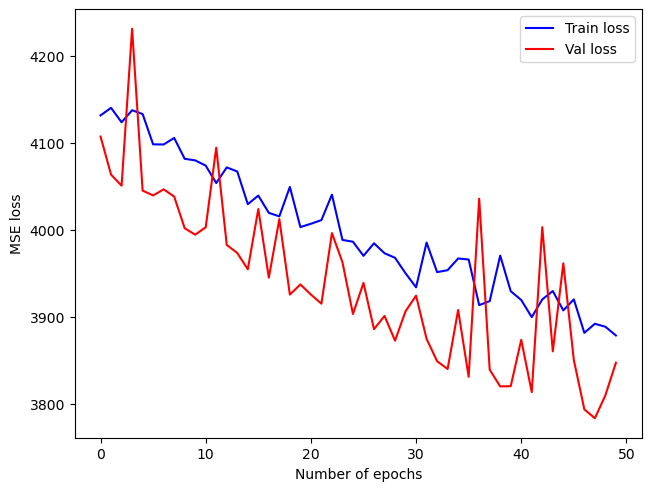

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(layout='constrained')
x = np.arange(0,max_iters,1)
color = "blue"
ax.plot(x, train_loss_list, color = color, label = 'Train loss')
color = "red"
ax.plot(x, val_loss_list, color = color, label = 'Val loss')
ax.set_xlabel("Number of epochs")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()